# 100 Ohm differential stripline benchmark

The stripline is a commonly used transmission line in printed circuit board (PCB) designs. Compared to the microstrip, the advantage of the stripline includes better shielding from EM interference, lower radiation loss, and better performance at higher frequencies. These strengths make it suitable for use in high-speed interconnects, where bandwidth, package size, and signal integrity are key concerns.

In this notebook, we will build a 100 Ohm edge-coupled differential stripline and simulate it from 1 to 70 GHz. We will demonstrate how to use the `TerminalWavePort` feature to perform both 2D mode solver and 3D FDTD analyses. The results will be compared with benchmark data from other commercial RF simulation software. 

<center><img src="./img/differential_stripline_render.png" width=480 /></center>

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import tidy3d as td
import tidy3d.rf as rf
import tidy3d.web as web
from tidy3d.plugins.dispersion import FastDispersionFitter

td.config.logging.level = "ERROR"

## Building the Simulation

### Key Parameters

We begin by defining some key parameters. The design impedance $Z_0$ for the differential mode will be 100 Ohms. The geometry parameters are chosen with that in mind. Material properties are assumed constant over the frequency band. 

<center><img src="./img/differential_stripline_schematic.png" width=400 /></center>

In [2]:
# Frequency range (Hz)
f_min, f_max = (1e9, 70e9)
f0 = (f_max + f_min) / 2
freqs = np.linspace(f_min, f_max, 101)

In [3]:
# Geometry
mil = 25.4  # conversion to mils to microns (default unit)
w = 3.2 * mil  # Signal strip width
t = 0.7 * mil  # Conductor thickness
h = 10.7 * mil  # Substrate thickness
se = 7 * mil  # Gap between edge-coupled pair
L = 4000 * mil  # Line length
L_sub, W_sub = (L + 4 * mil, 50 * mil)  # Substrate length and width

In [4]:
# Material properties
cond = 60  # Metal conductivity in S/um
eps = 4.4  # Relative permittivity, substrate
losstan = 0.0012  # Loss tangent, substrate

### Mediums and Structures

We define the simulation mediums below. Loss is assumed constant over the frequency band. 
* Metal: The [`LossyMetalMedium`](https://docs.flexcompute.com/projects/tidy3d/en/latest/api/_autosummary/tidy3d.LossyMetalMedium.html) feature implements the surface impedance boundary condition for lossy metals .
* Dielectric: The [`constant_loss_tangent_model`](https://docs.flexcompute.com/projects/tidy3d/en/latest/api/_autosummary/tidy3d.plugins.dispersion.FastDispersionFitter.html#tidy3d.plugins.dispersion.FastDispersionFitter.constant_loss_tangent_model) method in the [`FastDispersionFitter`](https://docs.flexcompute.com/projects/tidy3d/en/latest/api/_autosummary/tidy3d.plugins.dispersion.FastDispersionFitter.html) plugin automatically generates a `PoleResidue` medium given permittivity, loss tangent, and frequency range parameters. 

In [5]:
med_sub = FastDispersionFitter.constant_loss_tangent_model(
    eps, losstan, (f_min, f_max), tolerance_rms=2e-4
)
med_metal = rf.LossyMetalMedium(conductivity=cond, frequency_range=(f_min, f_max), name="Metal")

Output()

We use the `VisualizationSpec` feature to control the fill color of the materials during python plotting.

In [6]:
med_sub = med_sub.updated_copy(
    viz_spec=td.VisualizationSpec(facecolor="#7cc48d")
)  # green tone for substrate
med_metal = med_metal.updated_copy(
    viz_spec=td.VisualizationSpec(facecolor="#ce7e00")
)  # brown tone for metal

The structures are created below. 

In [7]:
# Substrate
str_sub = td.Structure(geometry=td.Box(center=(0, 0, 0), size=(W_sub, h, L_sub)), medium=med_sub)

# Signal strips
str_strip_left = td.Structure(
    geometry=td.Box(center=(-(se + w) / 2, 0, 0), size=(w, t, L_sub)), medium=med_metal
)
str_strip_right = td.Structure(
    geometry=td.Box(center=((se + w) / 2, 0, 0), size=(w, t, L_sub)), medium=med_metal
)

# Top and bottom ground planes
str_gnd_top = td.Structure(
    geometry=td.Box(center=(0, h / 2 + t / 2, 0), size=(W_sub, t, L_sub)), medium=med_metal
)
str_gnd_bot = td.Structure(
    geometry=td.Box(center=(0, -h / 2 - t / 2, 0), size=(W_sub, t, L_sub)), medium=med_metal
)

### Grid and Boundaries

The [`LayerRefinementSpec`](https://docs.flexcompute.com/projects/tidy3d/en/latest/api/_autosummary/tidy3d.LayerRefinementSpec.html) feature controls grid refinement around metallic structures. We apply extra refinement around the signal traces, and basic refinement for the top and bottom ground planes. 

In [8]:
# Create a LayerRefinementSpec from signal trace structures
lr1 = rf.LayerRefinementSpec.from_structures(
    structures=[str_strip_left, str_strip_right],
    min_steps_along_axis=10,  # Min 10 grid cells along normal direction
    corner_refinement=td.GridRefinement(
        dl=t / 10, num_cells=2
    ),  # snap to corners and apply added refinement
)

# Layer refinement for top and bottom ground planes
lr2 = rf.LayerRefinementSpec(
    center=(0, h / 2 + t / 2, 0), size=(td.inf, t, td.inf), axis=1, min_steps_along_axis=2
)
lr3 = lr2.updated_copy(center=(0, -h / 2 - t / 2, 0))

The rest of the grid is automatically generated based on the wavelength. 

In [9]:
# Define overall grid specification
grid_spec = td.GridSpec.auto(
    wavelength=td.C_0 / f_max,
    min_steps_per_wvl=18,
    layer_refinement_specs=[lr1, lr2, lr3],
)

The top (`+y`) and bottom (`-y`) boundaries of this model are adjacent to the metal ground planes and can be set to PEC. All other boundaries are open and thus truncated by perfectly matched layers (PMLs).

In [10]:
boundary_spec = td.BoundarySpec(
    x=td.Boundary.pml(),
    y=td.Boundary.pec(),
    z=td.Boundary.pml(),
)

### Monitors

For visualization purposes, we add a `FieldMonitor` between the signal plane and the bottom ground plane. 

In [11]:
mon_1 = td.FieldMonitor(
    center=(0, -h / 4, 0),
    size=(td.inf, 0, td.inf),
    freqs=[f_max],
    name="monitor 1",
)

### Terminal Wave Port

The `TerminalWavePort` feature is used to excite TEM modes in terminal-based structures. It is most suitable for single- and multi-ended transmission lines in PCBs and related applications.

Within each port plane, the port boundary should enclose all signal traces and touch/contact any adjacent ground planes for best results. All enclosed traces are automatically detected and assigned name labels `T0, T1, ...` in left-to-right, bottom-to-top order. 

For differential/common mode excitations, use the optional `differential_pairs` parameter to group each double-ended pair of terminals. Below, we assign the grouping `('T0', 'T1')` to indicate that the two signal traces are to be treated as a double-ended line. 

In [12]:
WP1 = rf.TerminalWavePort(
    center=(0, 0, -L / 2),
    size=(W_sub, h, 0),
    direction="+",
    name="WP1",
    differential_pairs=[("T0", "T1")],
)
WP2 = WP1.updated_copy(
    center=(0, 0, L / 2),
    direction="-",
    name="WP2",
)

### Define the Simulation and TerminalComponentModeler

The `Simulation` object in Tidy3D contains information about the entire simulation environment, including boundary conditions, grid, structures, and monitors.

In [13]:
sim = td.Simulation(
    size=(W_sub, h + 2 * t, L_sub),
    center=(0, 0, 0),
    grid_spec=grid_spec,
    boundary_spec=boundary_spec,
    structures=[str_sub, str_strip_left, str_strip_right, str_gnd_top, str_gnd_bot],
    monitors=[mon_1],
    run_time=2e-9,
    shutoff=1e-7,
    plot_length_units="mil",
)

The [`TerminalComponentModeler`](https://docs.flexcompute.com/projects/tidy3d/en/latest/api/_autosummary/tidy3d.plugins.smatrix.TerminalComponentModeler.html) conducts a port sweep based on our previously defined `Simulation` in order to construct the full S-parameter matrix.   

In [14]:
tcm = rf.TerminalComponentModeler(
    simulation=sim,
    ports=[WP1, WP2],  # terminal wave ports
    freqs=freqs,  # S-parameter frequency points
)

Below, we plot the wave port plane of `WP1` and the simulation grid (gray lines). The two terminals `T0` and `T1` are labeled, as well as the double-ended pair `Diff0`. 

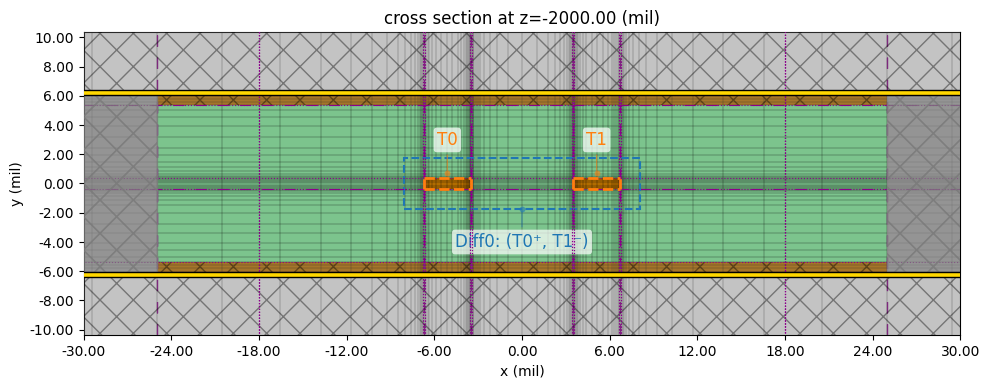

In [15]:
# Inspect transverse grid
fig, ax = plt.subplots(figsize=(10, 6), tight_layout=True)
sim.plot_grid(z=1, ax=ax)
tcm.plot_port("WP1", ax=ax)
plt.show()

## 2D Analysis

In this section, we demo a 2D `ModeSolver` calculation. This calculation provides the key transmission line parameters, such as attenuation $\alpha$, characteristic impedance $Z_0$, and effective index $n_{\text{eff}}$. 

The `ModeSolver` calculation can be easily constructed using one of the previously defined wave ports.

In [16]:
# Convert wave port to mode solver
mode_solver = WP1.to_mode_solver(simulation=sim, freqs=np.linspace(f_min, f_max, 51))

We submit the mode solver job below. 

In [17]:
mode_data = td.web.run(mode_solver, task_name="mode solver")

12:20:51 EDT Loading simulation from local cache. View cached task using web UI 
             at                                                                 
             ]8;id=127791;https://tidy3d.simulation.cloud/workbench?taskId=mo-f14271c5-e00e-4433-90cf-cda95ece6d8e\'https://tidy3d.simulation.cloud/workbench?]8;;\]8;id=685966;https://tidy3d.simulation.cloud/workbench?taskId=mo-f14271c5-e00e-4433-90cf-cda95ece6d8e\taskId]8;;\]8;id=127791;https://tidy3d.simulation.cloud/workbench?taskId=mo-f14271c5-e00e-4433-90cf-cda95ece6d8e\=]8;;\]8;id=771953;https://tidy3d.simulation.cloud/workbench?taskId=mo-f14271c5-e00e-4433-90cf-cda95ece6d8e\mo]8;;\]8;id=127791;https://tidy3d.simulation.cloud/workbench?taskId=mo-f14271c5-e00e-4433-90cf-cda95ece6d8e\-f14271c5-e00e-]8;;\
             ]8;id=127791;https://tidy3d.simulation.cloud/workbench?taskId=mo-f14271c5-e00e-4433-90cf-cda95ece6d8e\4433-90cf-cda95ece6d8e']8;;\.

Because there are two terminals in the `TerminalWavePort`, the mode solver data will include two modes. The `Ex` and `Ey` field profiles of both modes are shown below. 

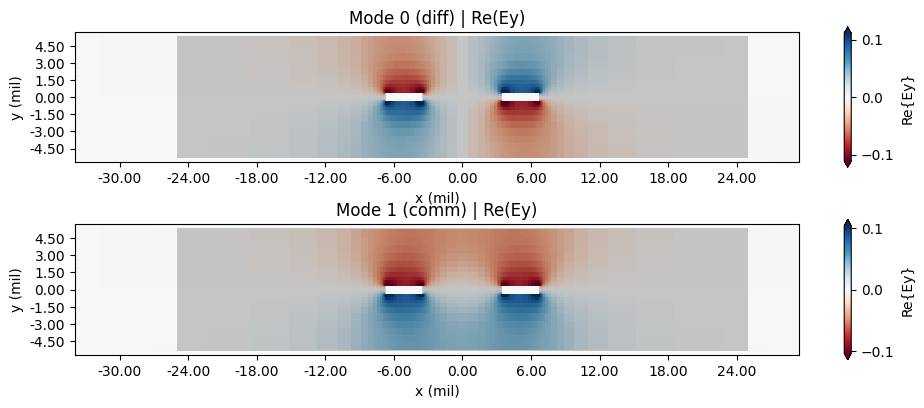

In [18]:
# Plot mode field
fig, ax = plt.subplots(2, 1, figsize=(10, 4), tight_layout=True)
mode_solver.plot_field(field_name="Ey", val="real", mode_index=0, f=f0, ax=ax[0])
mode_solver.plot_field(field_name="Ey", val="real", mode_index=1, f=f0, ax=ax[1])

ax[0].set_title("Mode 0 (diff) | Re(Ey)")
ax[1].set_title("Mode 1 (comm) | Re(Ey)")
plt.show()

In the analysis below, we will concentrate on the differential mode (`mode_index=0`). 

The 2D solution data includes effective index $n_{\text{eff}}$ and attenuation $\alpha$. (The complex propagation constant $\gamma$ is also available but not shown.)

In [19]:
# Gather alpha, neff from mode solver results
neff_mode = mode_data.modes_info["n eff"].isel(mode_index=0).squeeze()
alphadB_mode = mode_data.modes_info["loss (dB/cm)"].isel(mode_index=0).squeeze()

We obtain the differential impedance $Z_0$ from the full Z-matrix below. The `terminal_label_in` and `terminal_label_out` indices specify which row and column of the Z-matrix to extract. The naming scheme is `<diff_pair_name>@<diff OR comm>`.

In [20]:
Z0_mode = mode_data.transmission_line_terminal_data.Z0.sel(
    terminal_label_in="Diff0@diff", terminal_label_out="Diff0@diff"
)

Let's import some benchmark data for comparison. We will use mode data from a commercial FEM and FIT solver respectively. 

In [21]:
# Import benchmark data
freqs_ben1, neff_ben1, alphadB_ben1, Z0_ben1 = np.loadtxt(
    "./misc/stripline_fem_mode.csv", delimiter=",", skiprows=1, unpack=True
)
freqs_ben2, neff_ben2, alphadB_ben2, Z0_ben2 = np.loadtxt(
    "./misc/stripline_fit_mode.txt", delimiter=",", unpack=True
)

Let's compare the effective index $n_{\text{eff}}$.

In [22]:
def plot_data_and_band(data, err_band, ax, label=""):
    """Plots frequency-domain data together with a fractional error band"""
    ax.plot(data.f / 1e9, data, label=label, color="#328362")
    ax.fill_between(
        data.f / 1e9,
        (1 + err_band) * data,
        (1 - err_band) * data,
        alpha=0.5,
        color="#DDDDDD",
        label=f"+/-{err_band * 100:.2f}%",
    )
    ax.legend()

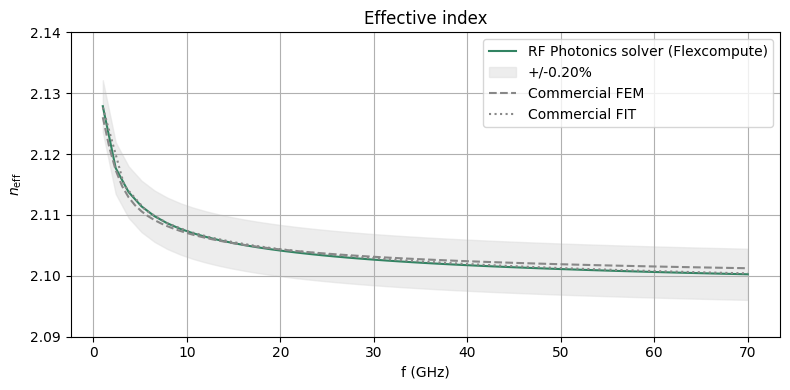

In [23]:
fig, ax = plt.subplots(figsize=(8, 4), tight_layout=True)
plot_data_and_band(neff_mode, 0.002, ax=ax, label="RF Photonics solver (Flexcompute)")
ax.plot(freqs_ben1, neff_ben1, "--", color="#888888", label="Commercial FEM")
ax.plot(freqs_ben2, neff_ben2, ":", color="#888888", label="Commercial FIT")
ax.set_title("Effective index")
ax.set_xlabel("f (GHz)")
ax.set_ylabel("$n_{\\text{eff}}$")
ax.set_ylim(2.09, 2.14)
ax.legend()
ax.grid()
plt.show()

We observe that $n_{\text{eff}}$ is in good agreement with the benchmarks, and is close to the substrate index $\sqrt \epsilon \approx 2.10$.

Next, let's compare the transmission line losses $\alpha$ (dB/cm).

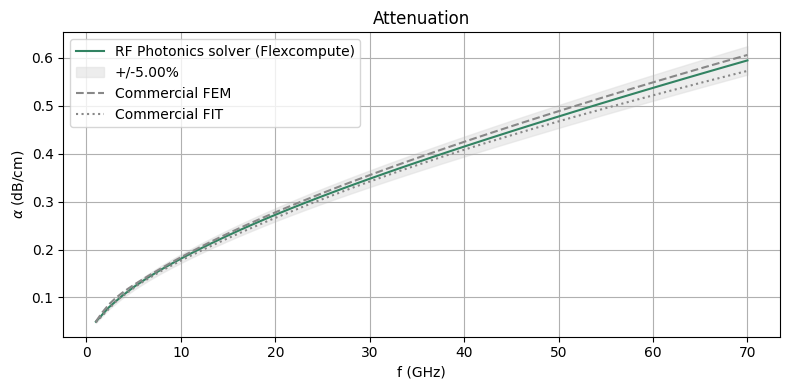

In [24]:
fig, ax = plt.subplots(figsize=(8, 4), tight_layout=True)
plot_data_and_band(alphadB_mode, 0.05, ax=ax, label="RF Photonics solver (Flexcompute)")
ax.plot(freqs_ben1, alphadB_ben1, "--", color="#888888", label="Commercial FEM")
ax.plot(freqs_ben2, alphadB_ben2, ":", color="#888888", label="Commercial FIT")
ax.set_title("Attenuation")
ax.set_xlabel("f (GHz)")
ax.set_ylabel("$\\alpha$ (dB/cm)")
ax.legend()
ax.grid()
plt.show()

Although the metal and substrate mediums are both lossy in this simulation, the metal losses dominate in this frequency range and scale as $f^{1/2}$ due to the skin depth. 

Let's compare the impedance $Z_0$ of the differential mode. 

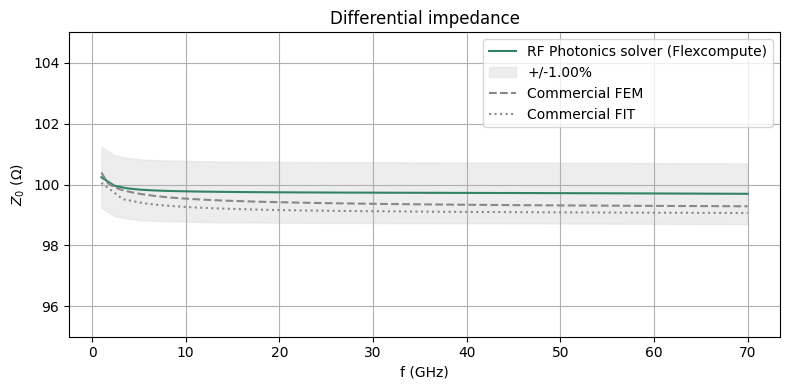

In [25]:
fig, ax = plt.subplots(figsize=(8, 4), tight_layout=True)
plot_data_and_band(np.real(Z0_mode), 0.01, ax=ax, label="RF Photonics solver (Flexcompute)")
ax.plot(freqs_ben1, Z0_ben1, "--", color="#888888", label="Commercial FEM")
ax.plot(freqs_ben2, Z0_ben2, ":", color="#888888", label="Commercial FIT")
ax.set_title("Differential impedance")
ax.set_xlabel("f (GHz)")
ax.set_ylabel("$Z_0$ ($\\Omega$)")
ax.set_ylim(95, 105)
ax.legend()
ax.grid()
plt.show()

## 3D Analysis

For a longitudinally-invariant transmission line, the 2D mode solution fully defines its propagation characteristics and the 3D solution is not needed. However, for demonstration purposes, we will perform the 3D FDTD analysis to obtain the differential S21 parameter `SDD21`. The line length is 4 inches, which is tens of wavelengths at 70 GHz.

S-parameter convergence typically requires a lower level of grid refinement than the 2D mode solution. We reduce the grid refinement below to cut down on computational cost. 

In [26]:
# Update layer refinement with reduced fidelity
lr4 = lr1.updated_copy(
    min_steps_along_axis=3,
    corner_refinement=td.GridRefinement(dl=t / 2, num_cells=2),
)

# Update overall grid specification
grid_spec_3d = grid_spec.updated_copy(layer_refinement_specs=[lr2, lr3, lr4])

Since the transmission line is symmetric and there will be no coupling between the two modes, we only need to run the differential mode of one wave port `WP1`. This further reduces simulation cost. 

In [27]:
# Update sim and TCM
sim_3d = sim.updated_copy(grid_spec=grid_spec_3d)
tcm_3d = tcm.updated_copy(simulation=sim_3d, run_only=["WP1@Diff0@diff"])

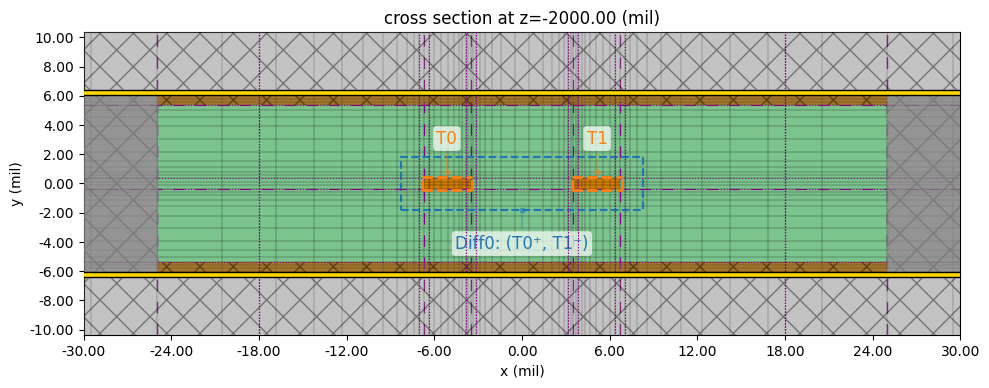

In [28]:
# Inspect transverse grid
fig, ax = plt.subplots(figsize=(10, 6), tight_layout=True)
sim_3d.plot_grid(z=1, ax=ax)
tcm_3d.plot_port("WP1", ax=ax)
plt.show()

The job is submitted below. 

In [29]:
tcm_data = web.run(tcm_3d, task_name="diff_stripline_3d")

12:20:52 EDT Loading simulation from local cache. View cached task using web UI 
             at                                                                 
             ]8;id=391534;https://tidy3d.simulation.cloud/rf?taskId=sid-e545fc43-1a5e-4537-affb-a72fb76f50a2\'https://tidy3d.simulation.cloud/rf?]8;;\]8;id=884299;https://tidy3d.simulation.cloud/rf?taskId=sid-e545fc43-1a5e-4537-affb-a72fb76f50a2\taskId]8;;\]8;id=391534;https://tidy3d.simulation.cloud/rf?taskId=sid-e545fc43-1a5e-4537-affb-a72fb76f50a2\=]8;;\]8;id=136431;https://tidy3d.simulation.cloud/rf?taskId=sid-e545fc43-1a5e-4537-affb-a72fb76f50a2\sid]8;;\]8;id=391534;https://tidy3d.simulation.cloud/rf?taskId=sid-e545fc43-1a5e-4537-affb-a72fb76f50a2\-e545fc43-1a5e-4537-a]8;;\
             ]8;id=391534;https://tidy3d.simulation.cloud/rf?taskId=sid-e545fc43-1a5e-4537-affb-a72fb76f50a2\ffb-a72fb76f50a2']8;;\.

We use the `port_in` and `port_out` parameters to select the corresponding entry of the S-matrix. The naming scheme is `<port_name>@<differential_pair_name>@<diff OR comm>` for differential pairs. Below, we extract `SDD21`. 

In [30]:
# Get S-parameters
s_matrix = tcm_data.smatrix()
S21 = np.conjugate(s_matrix.data.sel(port_in="WP1@Diff0@diff", port_out="WP2@Diff0@diff"))

We compare the computed `SDD21` magnitude against benchmark data. 

In [31]:
# Import benchmark data
freqs_ben1, _, S21abs_ben1 = np.loadtxt(
    "./misc/stripline_fem_sparam_long.csv", delimiter=",", skiprows=1, unpack=True
)
freqs_ben2, _, S21abs_ben2 = np.loadtxt(
    "./misc/stripline_fit_sparams_long.txt", delimiter=",", unpack=True
)

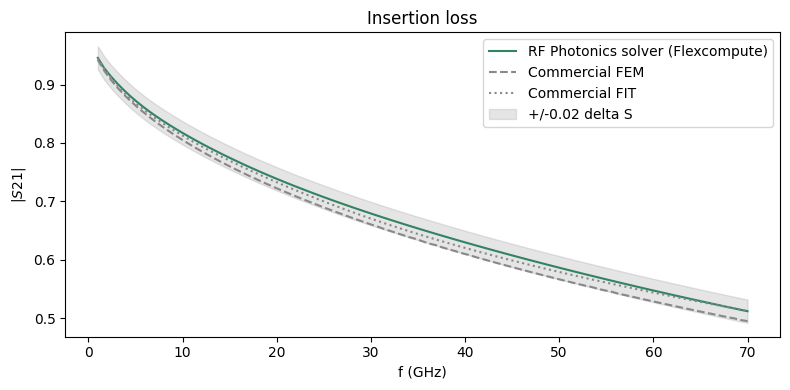

In [32]:
fig, ax = plt.subplots(figsize=(8, 4), tight_layout=True)
ax.plot(freqs / 1e9, np.abs(S21), label="RF Photonics solver (Flexcompute)", color="#328362")
ax.plot(freqs_ben1, S21abs_ben1, "--", color="#888888", label="Commercial FEM")
ax.plot(freqs_ben2, S21abs_ben2, ":", color="#888888", label="Commercial FIT")
ax.fill_between(
    freqs / 1e9,
    np.abs(S21) + 0.02,
    np.abs(S21) - 0.02,
    alpha=0.2,
    color="gray",
    label="+/-0.02 delta S",
)
ax.set_title("Insertion loss")
ax.set_ylabel("$|S21|$")
ax.set_xlabel("f (GHz)")
ax.legend()
plt.show()

In controlled testing, the RF solver is able to solve this relatively large model in about 3.5 minutes on two A100 GPUs.

For comparison, this problem took about 1 hour to solve using the commercial FIT software, and close to 12 hours using the commercial FEM software. Benchmarking was done using a 20-core desktop workstation with 256 GB of RAM. 

Below, we plot the `Ey` field profile recorded by the field monitor at max frequency.

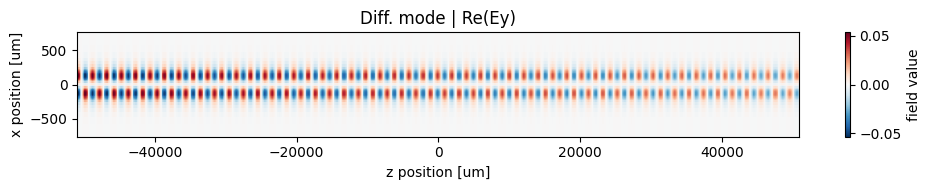

In [33]:
fig, ax = plt.subplots(figsize=(10, 2), tight_layout=True)
# Plotting diff mode
sim_data = tcm_data.data["WP1@Diff0@diff"]
ey = sim_data["monitor 1"].Ey.sel(f=f_max, method="nearest")
np.real(ey).plot(x="z", y="x", ax=ax)
ax.set_title("Diff. mode | Re(Ey)")
ax.set_ylim(-30 * mil, 30 * mil)
plt.show()